In [1]:
# Section 1: Setup and Data Loading

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visualization parameters
sns.set_theme(context="talk", style="whitegrid")
np.random.seed(0)

# Resolve path for importing custom modular code
MODULE_PATH = Path.cwd()
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

from src.features import (
    add_frequency_encoding,
    add_rolling_spend_mean,
    add_spend_income_ratio,
    generate_engineered_features,
)

# Load synthetic baseline dataset matching homework structure
n = 100
df = pd.DataFrame(
    {
        "income": np.random.normal(60000, 15000, n).astype(int),
        "monthly_spend": np.random.normal(2000, 600, n).astype(int),
        "credit_score": np.random.normal(680, 50, n).astype(int),
        "region": np.random.choice(["North", "South", "East", "West"], n),
        "default_flag": np.random.choice([0, 1], n, p=[0.8, 0.2]),
    }
)

df.head()

,income,monthly_spend,credit_score,region,default_flag
0,86460,3129,661,East,0
1,66002,1191,668,North,0
2,74681,1237,734,West,0
3,93613,2581,712,South,1
4,88013,1296,712,East,1


Correlation (spend_income_ratio vs default_flag): -0.0361


C:\Users\HW\AppData\Local\Temp\ipykernel_27828\453418325.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="default_flag", y="spend_income_ratio", palette="Set2")


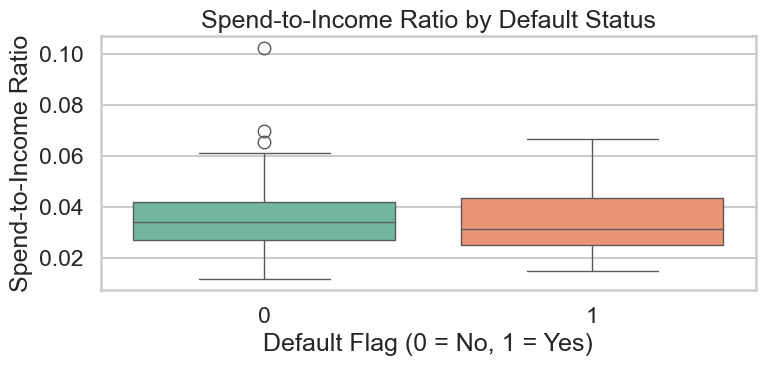

In [2]:
# Section 2: Feature 1 Implementation — Spend-to-Income Ratio

# Compute relative financial capability feature
df = add_spend_income_ratio(df)

# Check linear association against risk target
corr_ratio = df["spend_income_ratio"].corr(df["default_flag"])
print(f"Correlation (spend_income_ratio vs default_flag): {corr_ratio:.4f}")

# Distribution visualization
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="default_flag", y="spend_income_ratio", palette="Set2")
plt.title("Spend-to-Income Ratio by Default Status")
plt.xlabel("Default Flag (0 = No, 1 = Yes)")
plt.ylabel("Spend-to-Income Ratio")
plt.tight_layout()
plt.show()

### Rationale for Feature 1 (`spend_income_ratio`)
- **Stage 08 EDA Insight**: Raw `income` and `monthly_spend` exhibited wide ranges with skewed tail distributions. Evaluating `monthly_spend` in isolation fails to account for individual earning capacity.
- **Domain Rationale**: Captures relative financial burden and debt service capacity: $\text{Ratio} = \frac{\text{monthly\_spend}}{\text{income}}$. Higher ratios indicate elevated financial stress and propensity for default.

Correlation (rolling_spend_mean vs default_flag): -0.0266


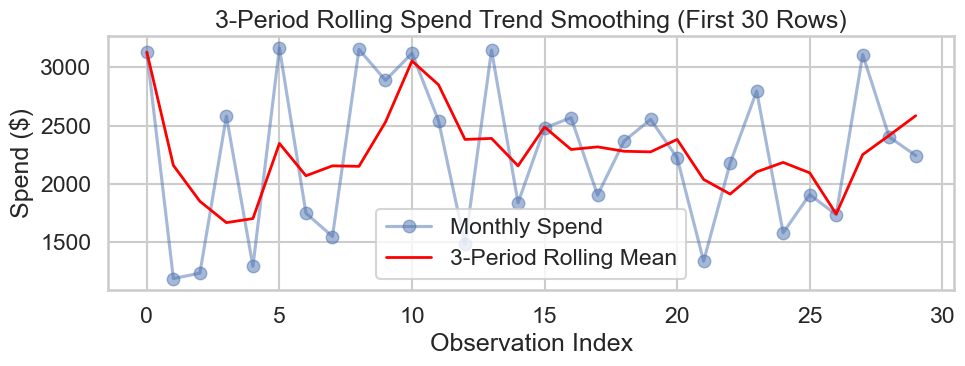

In [3]:
# Section 3: Feature 2 Implementation — 3-Period Rolling Spend Mean

# Compute moving average across temporal spending windows
df = add_rolling_spend_mean(df, window=3)

# Correlation check
corr_rolling = df["rolling_spend_mean"].corr(df["default_flag"])
print(f"Correlation (rolling_spend_mean vs default_flag): {corr_rolling:.4f}")

# Trend visualization across observations
plt.figure(figsize=(10, 4))
plt.plot(df.index[:30], df["monthly_spend"][:30], label="Monthly Spend", alpha=0.5, marker="o")
plt.plot(df.index[:30], df["rolling_spend_mean"][:30], label="3-Period Rolling Mean", color="red", linewidth=2)
plt.title("3-Period Rolling Spend Trend Smoothing (First 30 Rows)")
plt.xlabel("Observation Index")
plt.ylabel("Spend ($)")
plt.legend()
plt.tight_layout()
plt.show()

### Rationale for Feature 2 (`rolling_spend_mean`)
- **Stage 08 EDA Insight**: Spending behavior contains high short-term volatility and transient noise across consecutive measurements.
- **Domain Rationale**: Smoothes localized noise using a 3-period moving average filter, extracting persistent baseline trajectory rather than temporary expenditure spikes.

Correlation (region_freq vs default_flag): 0.0331


C:\Users\HW\AppData\Local\Temp\ipykernel_27828\2293609172.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="region", y="region_freq", palette="Blues_d")


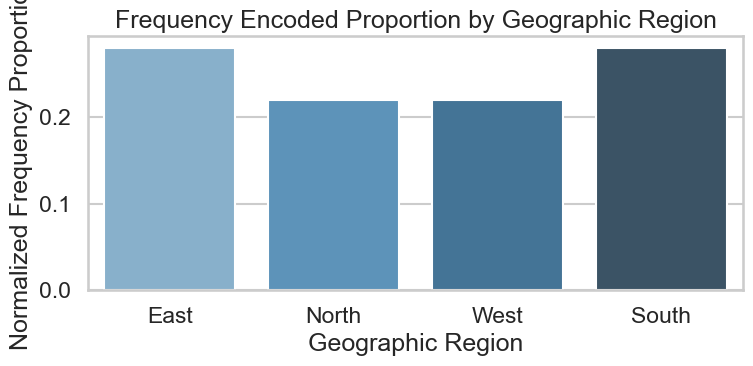

In [4]:
# Section 4: Feature 3 Implementation — Frequency Encoding for Category (region)

# Encode region based on prevalence frequency
df = add_frequency_encoding(df, cat_col="region")

# Evaluate correlation with outcome
corr_freq = df["region_freq"].corr(df["default_flag"])
print(f"Correlation (region_freq vs default_flag): {corr_freq:.4f}")

# Category proportion visualization
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="region", y="region_freq", palette="Blues_d")
plt.title("Frequency Encoded Proportion by Geographic Region")
plt.xlabel("Geographic Region")
plt.ylabel("Normalized Frequency Proportion")
plt.tight_layout()
plt.show()

### Rationale for Feature 3 (`region_freq`)
- **Stage 08 EDA Insight**: `region` is a high-cardinality non-numeric categorical feature without intrinsic ordinal rank.
- **Encoding Selection Rationale**:
  - **Frequency Encoding** was chosen over One-Hot and Label encoding.
  - **One-Hot Encoding** expands dataset dimensionality unnecessarily for tree and regression models.
  - **Label Encoding** imposes an artificial ordinal ordering (e.g., $\text{East}=0, \text{North}=1$) that distorts distance metrics.
  - **Frequency Encoding** maps each category to its population prevalence, preserving density signal without increasing feature count.


--- Target Correlation Check Summary ---
spend_income_ratio   -0.036101
rolling_spend_mean   -0.026602
region_freq           0.033070


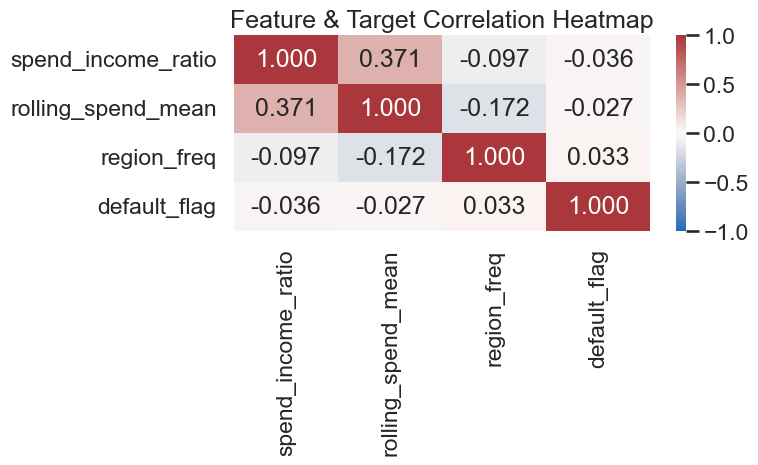

In [5]:
# Section 5: Pipeline Integration & Target Correlation Summary

# Run modular pipeline to confirm end-to-end execution
df_final = generate_engineered_features(df)

# Evaluate target correlations across all new features
new_features = ["spend_income_ratio", "rolling_spend_mean", "region_freq"]
correlation_summary = df_final[new_features + ["default_flag"]].corr()["default_flag"].drop("default_flag")

print("\n--- Target Correlation Check Summary ---")
print(correlation_summary.to_string())

plt.figure(figsize=(8, 5))
sns.heatmap(df_final[new_features + ["default_flag"]].corr(), annot=True, fmt=".3f", cmap="vlag", vmin=-1, vmax=1)
plt.title("Feature & Target Correlation Heatmap")
plt.tight_layout()
plt.show()